# Problem Title - Library Mode
Issue: #<issue-number>

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

In [83]:
import pandas as pd

df = pd.read_csv("../dataset.csv")
print(df.head())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  quality_binary  
0      9.4        5               0  
1      9.8

In [84]:
X = df.drop(columns=["quality", "quality_binary"])
y = df["quality_binary"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
import torch

X_train = torch.tensor(X_train.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

In [87]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 32)
        self.act = activation
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

In [88]:
activations = {
    "ReLU": nn.ReLU(),
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh()
}

loss_history = {}

In [89]:
for name, act in activations.items():
    model = Net(act)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []

    for epoch in range(50):
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    loss_history[name] = losses

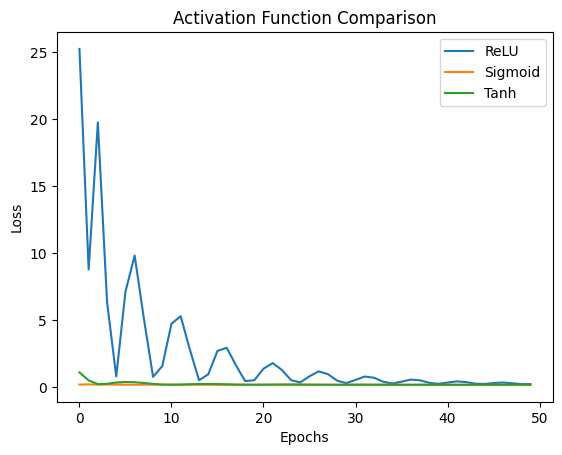

In [90]:
import matplotlib.pyplot as plt

for name, losses in loss_history.items():
    plt.plot(losses, label=name)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Activation Function Comparison")
plt.legend()
plt.show()

## Conclusion

From the plotted training loss curves, ReLU converges the fastest among the three activation functions, followed by Tanh, while Sigmoid shows the slowest convergence. ReLU exhibits a sharp decline in loss during the initial epochs, indicating rapid learning, whereas Sigmoid decreases gradually, suggesting slower optimization. Tanh performs better than Sigmoid but still lags behind ReLU.

This difference arises due to the nature of the activation functions. ReLU avoids the vanishing gradient problem for positive inputs, allowing efficient gradient propagation and faster updates. In contrast, Sigmoid squashes values between 0 and 1, leading to very small gradients and slower learning. Tanh, although zero-centered and better than Sigmoid, still suffers from saturation at extreme values, which slows down convergence.

Hence, ReLU is generally more effective for hidden layers in neural networks due to its faster convergence and better gradient flow.
